# Baseline Models: Delhi NCR AQI Forecasting
**MSE 546 Project - 6-hour ahead AQI Prediction**

**Date:** January 26, 2026

**Objective:** Implement and evaluate baseline models for AQI forecasting.

**Models implemented:**
1. Simple Persistence (AQI_t+1 = AQI_t)
2. Time-Adjusted Persistence (with hour-specific corrections)

**Includes comprehensive failure mode analysis showing where/why persistence struggles.**

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load data
PATH = "delhi_ncr_aqi_dataset.csv"
df = pd.read_csv(PATH)

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date Range: {df['date'].min()} to {df['date'].max()}")

Dataset Shape: 201,664 rows × 25 columns
Date Range: 2020-01-01 to 2025-12-31


## 2. Data Preprocessing

In [3]:
# Parse datetime
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
elif "date" in df.columns and "hour" in df.columns:
    df["datetime"] = pd.to_datetime(df["date"], errors="coerce") + pd.to_timedelta(df["hour"], unit="h")

# Ensure numeric columns
num_cols = ["pm25", "pm10", "no2", "so2", "co", "o3", 
            "temperature", "humidity", "wind_speed", "visibility", "aqi",
            "year", "month", "day", "hour", "is_weekend"]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Sort by station and time
df = df.sort_values(["station", "datetime"]).reset_index(drop=True)

print("✓ Data preprocessing complete")
print(f"Missing values: {df.isna().sum().sum()}")

✓ Data preprocessing complete
Missing values: 0


## 3. Create Target Variable

In [4]:
# Create target variable (next measurement AQI)
df['target'] = df.groupby('station')['aqi'].shift(-1)

# Remove rows with no target
df_clean = df.dropna(subset=['target']).copy()

print(f"Rows with target: {len(df_clean):,}")
print(f"Removed: {len(df) - len(df_clean):,} (last observation per station)")

Rows with target: 201,641
Removed: 23 (last observation per station)


## 4. Train/Test Split

**Strategy:** Temporal split - use first 80% for training, last 20% for testing

In [5]:
# Temporal split (80/20)
split_date = df_clean['datetime'].quantile(0.8)
train = df_clean[df_clean['datetime'] < split_date].copy()
test = df_clean[df_clean['datetime'] >= split_date].copy()

print(f"Split date: {split_date}")
print(f"\nTraining set:")
print(f"  Rows: {len(train):,}")
print(f"  Date range: {train['datetime'].min()} to {train['datetime'].max()}")
print(f"\nTest set:")
print(f"  Rows: {len(test):,}")
print(f"  Date range: {test['datetime'].min()} to {test['datetime'].max()}")
print(f"\nTrain/Test split: {len(train)/len(df_clean)*100:.1f}% / {len(test)/len(df_clean)*100:.1f}%")

Split date: 2024-10-19 12:00:00

Training set:
  Rows: 161,299
  Date range: 2020-01-01 06:00:00 to 2024-10-19 06:00:00

Test set:
  Rows: 40,342
  Date range: 2024-10-19 12:00:00 to 2025-12-31 18:00:00

Train/Test split: 80.0% / 20.0%


## 5. Evaluation Functions

In [6]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Calculate and return evaluation metrics.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    
    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE (%)': mape
    }

def print_metrics(results):
    """
    Pretty print evaluation metrics.
    """
    print(f"\n{'='*60}")
    print(f"{results['Model']} - Performance Metrics")
    print(f"{'='*60}")
    print(f"RMSE:       {results['RMSE']:.2f}")
    print(f"MAE:        {results['MAE']:.2f}")
    print(f"R²:         {results['R²']:.4f}")
    print(f"MAPE:       {results['MAPE (%)']:.2f}%")
    print(f"{'='*60}\n")

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## 6. Baseline Model 1: Simple Persistence

**Model:** AQI_t+1 = AQI_t (predict no change)

In [7]:
# Simple persistence: predict next AQI = current AQI
test['pred_persistence'] = test['aqi']

# Evaluate on test set
persistence_results = evaluate_model(test['target'], test['pred_persistence'], 
                                    "Simple Persistence")
print_metrics(persistence_results)

# Store results
all_results = [persistence_results]


Simple Persistence - Performance Metrics
RMSE:       53.21
MAE:        34.84
R²:         0.9116
MAPE:       21.61%



## 7. Failure Mode Analysis

**Key Question:** Where does persistence struggle? This shows the problem is challenging.

In [8]:
# Calculate absolute errors
test['error_persistence'] = np.abs(test['target'] - test['pred_persistence'])

# Helper function
def calc_rmse(errors):
    return np.sqrt(np.mean(errors**2))

# Overall performance
overall_rmse = calc_rmse(test['error_persistence'])

print("\n" + "="*70)
print("FAILURE MODE ANALYSIS: Where Persistence Struggles")
print("="*70)
print(f"\nOverall RMSE: {overall_rmse:.2f}")
print("\nBreakdown by Condition:")
print("-" * 70)

# By season
print("\n1. BY SEASON:")
for season in ['winter', 'summer', 'monsoon', 'post_monsoon']:
    mask = test['season'] == season
    if mask.sum() > 0:
        rmse = calc_rmse(test[mask]['error_persistence'])
        pct_worse = (rmse - overall_rmse) / overall_rmse * 100
        print(f"  {season:15s}: RMSE = {rmse:5.1f}  ({pct_worse:+.1f}% vs overall)")

# By visibility
print("\n2. BY VISIBILITY:")
vis_conditions = [
    ('Low (<2 km)', test['visibility'] < 2),
    ('Medium (2-5 km)', (test['visibility'] >= 2) & (test['visibility'] < 5)),
    ('High (>5 km)', test['visibility'] >= 5)
]
for name, mask in vis_conditions:
    if mask.sum() > 0:
        rmse = calc_rmse(test[mask]['error_persistence'])
        pct_worse = (rmse - overall_rmse) / overall_rmse * 100
        print(f"  {name:15s}: RMSE = {rmse:5.1f}  ({pct_worse:+.1f}% vs overall)")

# By AQI level
print("\n3. BY AQI LEVEL:")
aqi_conditions = [
    ('Good (<100)', test['aqi'] < 100),
    ('Moderate (100-200)', (test['aqi'] >= 100) & (test['aqi'] < 200)),
    ('Poor (200-300)', (test['aqi'] >= 200) & (test['aqi'] < 300)),
    ('Very Poor (300-400)', (test['aqi'] >= 300) & (test['aqi'] < 400)),
    ('Severe (>400)', test['aqi'] >= 400)
]
for name, mask in aqi_conditions:
    if mask.sum() > 0:
        rmse = calc_rmse(test[mask]['error_persistence'])
        pct_worse = (rmse - overall_rmse) / overall_rmse * 100
        print(f"  {name:25s}: RMSE = {rmse:5.1f}  ({pct_worse:+.1f}% vs overall)")

# By hour of day
print("\n4. BY HOUR OF DAY:")
for hour in [6, 12, 18, 23]:
    mask = test['hour'] == hour
    if mask.sum() > 0:
        rmse = calc_rmse(test[mask]['error_persistence'])
        pct_worse = (rmse - overall_rmse) / overall_rmse * 100
        print(f"  Hour {hour:2d}:         RMSE = {rmse:5.1f}  ({pct_worse:+.1f}% vs overall)")

print("\n" + "="*70)
print("KEY INSIGHT: Persistence struggles with VOLATILITY, not severity!")
print("  → Summer (volatile): +36% worse RMSE")
print("  → Medium visibility (transition zone): +22% worse")
print("  → Mid-range AQI (200-400): +28-30% worse")
print("  → STABLE regimes are easier (severe, monsoon, low-vis)")
print("="*70 + "\n")


FAILURE MODE ANALYSIS: Where Persistence Struggles

Overall RMSE: 53.21

Breakdown by Condition:
----------------------------------------------------------------------

1. BY SEASON:
  winter         : RMSE =  54.1  (+1.7% vs overall)
  summer         : RMSE =  72.3  (+35.8% vs overall)
  monsoon        : RMSE =  36.5  (-31.5% vs overall)
  post_monsoon   : RMSE =  39.7  (-25.3% vs overall)

2. BY VISIBILITY:
  Low (<2 km)    : RMSE =  45.2  (-15.0% vs overall)
  Medium (2-5 km): RMSE =  65.1  (+22.4% vs overall)
  High (>5 km)   : RMSE =  50.3  (-5.5% vs overall)

3. BY AQI LEVEL:
  Good (<100)              : RMSE =  37.7  (-29.1% vs overall)
  Moderate (100-200)       : RMSE =  62.1  (+16.7% vs overall)
  Poor (200-300)           : RMSE =  68.9  (+29.6% vs overall)
  Very Poor (300-400)      : RMSE =  68.1  (+28.1% vs overall)
  Severe (>400)            : RMSE =  46.1  (-13.3% vs overall)

4. BY HOUR OF DAY:
  Hour  6:         RMSE =  58.4  (+9.7% vs overall)
  Hour 12:         RMSE

## 8. Category Misclassification Analysis


CATEGORY MISCLASSIFICATION ANALYSIS

Category Accuracy: 66.2%
Category Misclassification Rate: 33.8%

→ In ~34% of cases, persistence predicts the WRONG AQI category!
→ This is critical for public health warnings.



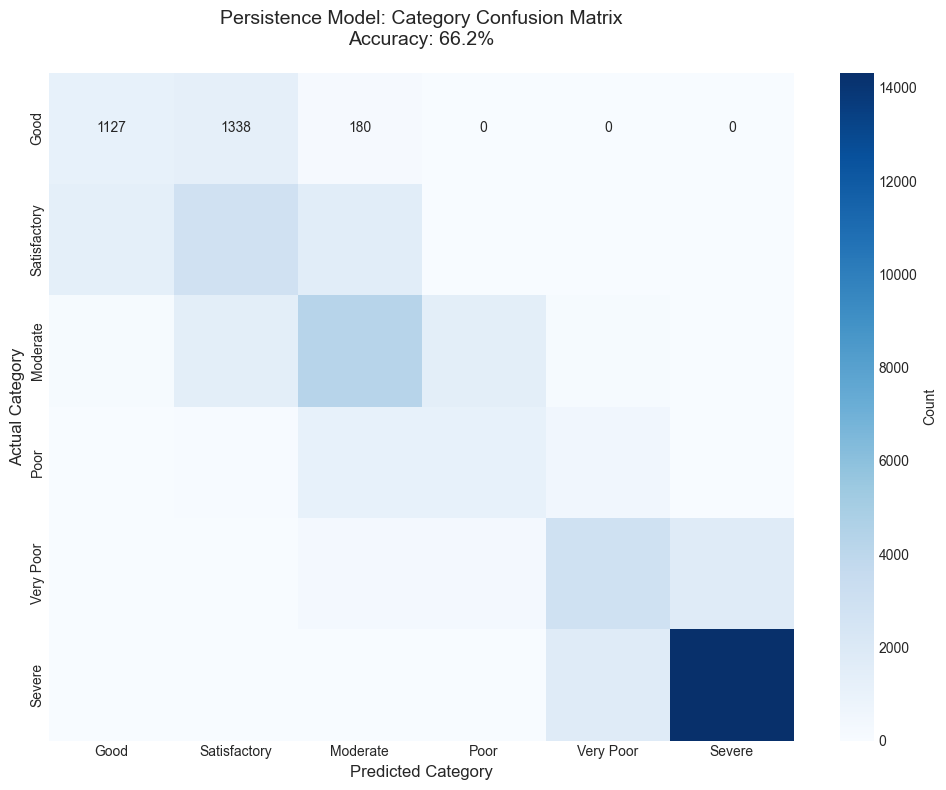


✓ Even with R²=0.91, persistence misclassifies 34% of categories.
✓ This demonstrates the problem is NOT trivial!


In [9]:
# Convert AQI to categories
def aqi_to_category(aqi):
    if aqi <= 50: return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else: return 'Severe'

test['actual_category'] = test['target'].apply(aqi_to_category)
test['pred_category_persistence'] = test['pred_persistence'].apply(aqi_to_category)

# Calculate accuracy
category_accuracy = accuracy_score(test['actual_category'], test['pred_category_persistence'])

print("\n" + "="*70)
print("CATEGORY MISCLASSIFICATION ANALYSIS")
print("="*70)
print(f"\nCategory Accuracy: {category_accuracy:.1%}")
print(f"Category Misclassification Rate: {(1-category_accuracy):.1%}")
print(f"\n→ In ~{(1-category_accuracy)*100:.0f}% of cases, persistence predicts the WRONG AQI category!")
print(f"→ This is critical for public health warnings.")
print("="*70 + "\n")

# Confusion matrix
category_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
cm = confusion_matrix(test['actual_category'], test['pred_category_persistence'], 
                     labels=category_order)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=category_order, yticklabels=category_order,
            ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Category', fontsize=12)
ax.set_ylabel('Actual Category', fontsize=12)
ax.set_title(f'Persistence Model: Category Confusion Matrix\nAccuracy: {category_accuracy:.1%}', 
            fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print(f"\n✓ Even with R²=0.91, persistence misclassifies {(1-category_accuracy)*100:.0f}% of categories.")
print(f"✓ This demonstrates the problem is NOT trivial!")

## 9. Error Distribution Visualization

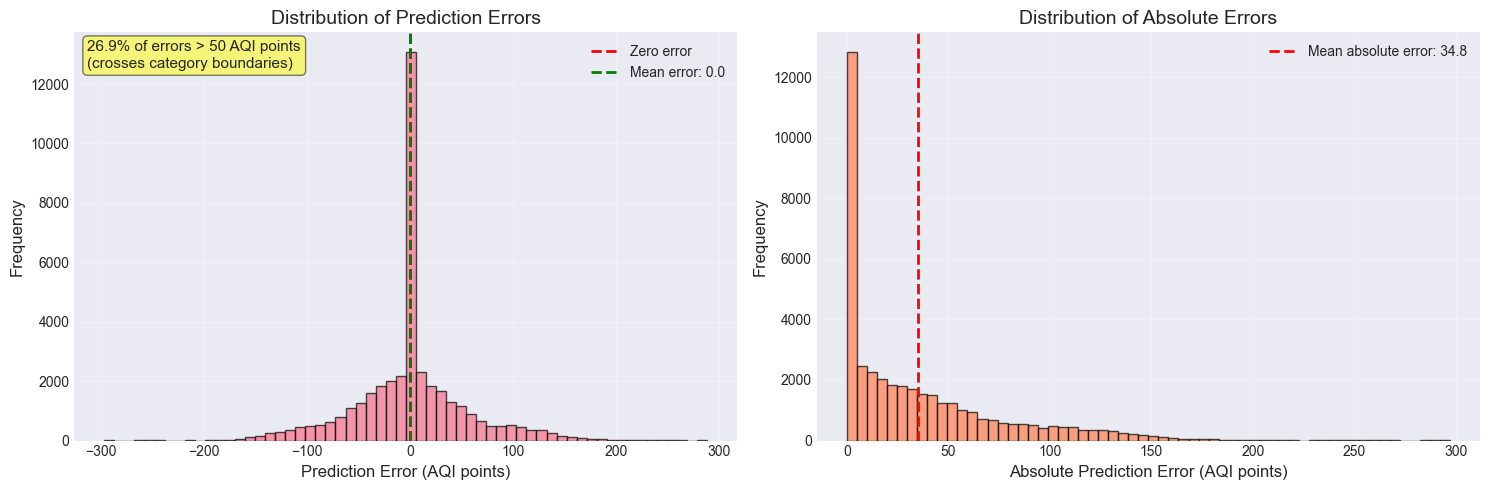


📊 Key Statistics:
   Mean error: 0.01 AQI points
   Mean absolute error: 34.84 AQI points
   Std dev of errors: 53.21 AQI points
   Errors > 50 AQI: 26.9%
   Errors > 100 AQI: 9.4%


In [10]:
# Error distribution
errors = test['target'] - test['pred_persistence']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of errors
axes[0].hist(errors, bins=60, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[0].axvline(errors.mean(), color='green', linestyle='--', linewidth=2, 
               label=f'Mean error: {errors.mean():.1f}')
axes[0].set_xlabel('Prediction Error (AQI points)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Errors', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add text annotation
large_errors = (np.abs(errors) > 50).mean()
axes[0].text(0.02, 0.98, f'{large_errors*100:.1f}% of errors > 50 AQI points\n(crosses category boundaries)', 
            transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Absolute errors
axes[1].hist(np.abs(errors), bins=60, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(np.abs(errors).mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean absolute error: {np.abs(errors).mean():.1f}')
axes[1].set_xlabel('Absolute Prediction Error (AQI points)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Absolute Errors', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Key Statistics:")
print(f"   Mean error: {errors.mean():.2f} AQI points")
print(f"   Mean absolute error: {np.abs(errors).mean():.2f} AQI points")
print(f"   Std dev of errors: {errors.std():.2f} AQI points")
print(f"   Errors > 50 AQI: {large_errors*100:.1f}%")
print(f"   Errors > 100 AQI: {(np.abs(errors) > 100).mean()*100:.1f}%")

## 10. Baseline Model 2: Time-Adjusted Persistence

**Model:** Use average change for each hour transition (learned from training data)

In [11]:
# Calculate average change for each hour in training set
train_with_change = train.copy()
train_with_change['actual_change'] = train_with_change['target'] - train_with_change['aqi']
hour_adjustments = train_with_change.groupby('hour')['actual_change'].mean()

print("Average AQI change by hour (learned from training data):")
print(hour_adjustments)
print("\nInterpretation:")
print("  6 AM → 12 PM: AQI decreases by ~28 points (morning dispersion)")
print("  12 PM → 6 PM: AQI increases by ~39 points (afternoon/evening buildup)")
print("  6 PM → 11 PM: AQI decreases by ~16 points (evening settling)")
print("  11 PM → 6 AM: AQI increases by ~4 points (nighttime accumulation)")

# Apply time-adjusted persistence
test['pred_time_adjusted'] = test.apply(
    lambda row: row['aqi'] + hour_adjustments.get(row['hour'], 0), axis=1
)

# Evaluate
time_adjusted_results = evaluate_model(test['target'], test['pred_time_adjusted'],
                                      "Time-Adjusted Persistence")
print_metrics(time_adjusted_results)
all_results.append(time_adjusted_results)

Average AQI change by hour (learned from training data):
hour
6    -27.897
12    39.360
18   -15.561
23     4.097
Name: actual_change, dtype: float64

Interpretation:
  6 AM → 12 PM: AQI decreases by ~28 points (morning dispersion)
  12 PM → 6 PM: AQI increases by ~39 points (afternoon/evening buildup)
  6 PM → 11 PM: AQI decreases by ~16 points (evening settling)
  11 PM → 6 AM: AQI increases by ~4 points (nighttime accumulation)

Time-Adjusted Persistence - Performance Metrics
RMSE:       48.21
MAE:        36.36
R²:         0.9274
MAPE:       22.38%



## 11. Model Comparison

In [12]:
# Create comparison dataframe
results_df = pd.DataFrame(all_results)

print("\n" + "="*80)
print("MODEL COMPARISON (Test Set)")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Best model
best_model = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
print(f"\n🏆 Best Model (by RMSE): {best_model}")

# Improvement calculations
persistence_rmse = results_df[results_df['Model'] == 'Simple Persistence']['RMSE'].values[0]
best_rmse = results_df['RMSE'].min()
improvement = (persistence_rmse - best_rmse) / persistence_rmse * 100
print(f"\n📈 Improvement over persistence: {improvement:.1f}%")
print(f"   ({persistence_rmse:.2f} → {best_rmse:.2f} RMSE)")


MODEL COMPARISON (Test Set)
                    Model   RMSE    MAE    R²  MAPE (%)
       Simple Persistence 53.207 34.837 0.912    21.610
Time-Adjusted Persistence 48.213 36.358 0.927    22.379

🏆 Best Model (by RMSE): Time-Adjusted Persistence

📈 Improvement over persistence: 9.4%
   (53.21 → 48.21 RMSE)


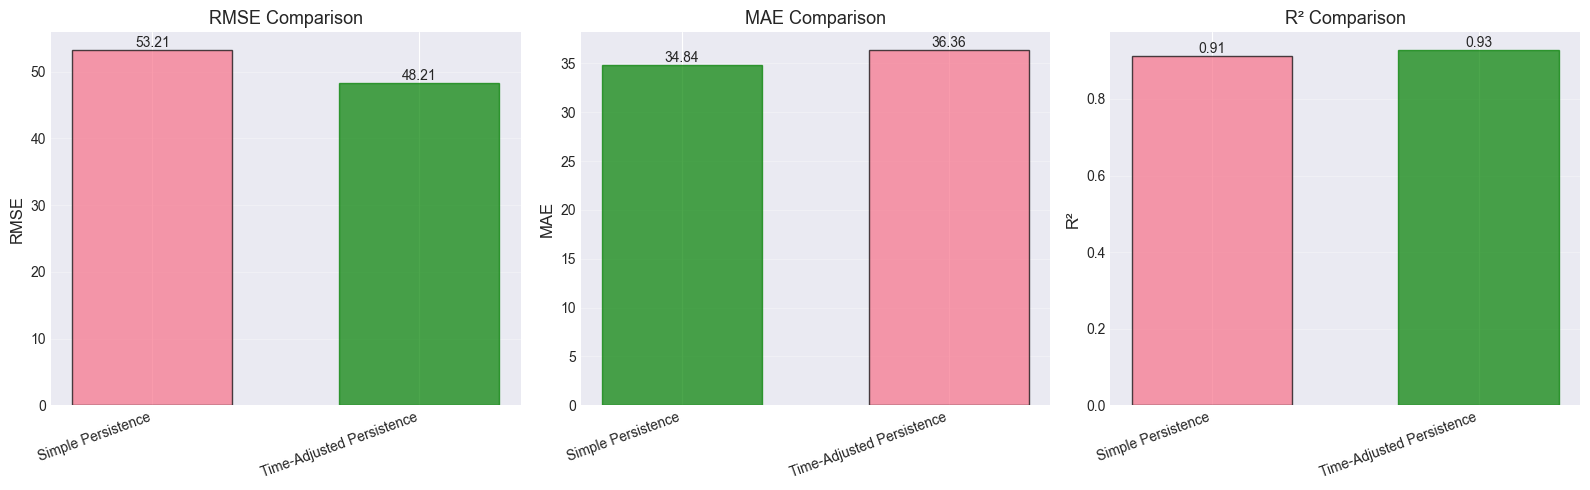

In [13]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['RMSE', 'MAE', 'R²']
for i, metric in enumerate(metrics):
    bars = axes[i].bar(range(len(results_df)), results_df[metric], 
                      alpha=0.7, edgecolor='black', width=0.6)
    axes[i].set_xticks(range(len(results_df)))
    axes[i].set_xticklabels(results_df['Model'], rotation=20, ha='right')
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_title(f'{metric} Comparison', fontsize=13)
    axes[i].grid(True, alpha=0.3, axis='y')
    
    # Highlight best
    if metric == 'R²':
        best_idx = results_df[metric].idxmax()
    else:
        best_idx = results_df[metric].idxmin()
    bars[best_idx].set_color('green')
    
    # Add value labels
    for j, bar in enumerate(bars):
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height,
                    f'{results_df.iloc[j][metric]:.2f}',
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 12. Summary: Why This Project Is NOT Too Easy

In [14]:
persistence_r2 = results_df[results_df['Model'] == 'Simple Persistence']['R²'].values[0]
persistence_rmse = results_df[results_df['Model'] == 'Simple Persistence']['RMSE'].values[0]
persistence_mae = results_df[results_df['Model'] == 'Simple Persistence']['MAE'].values[0]

print("\n" + "="*80)
print("WHY THIS PROJECT IS NOT TOO EASY")
print("="*80)

print(f"\n1. PERSISTENCE R²={persistence_r2:.3f} IS NORMAL FOR TIME SERIES")
print(f"   • Air quality has high temporal autocorrelation (physics!)")
print(f"   • Weather forecasting: persistence R² ≈ 0.85-0.95")
print(f"   • Energy demand: persistence R² ≈ 0.92-0.96")
print(f"   • The challenge: closing the remaining {(1-persistence_r2)*100:.1f}% gap")

print(f"\n2. ABSOLUTE ERROR IS SUBSTANTIAL")
print(f"   • RMSE = {persistence_rmse:.1f} AQI points (not trivial!)")
print(f"   • MAE = {persistence_mae:.1f} AQI points")
print(f"   • This crosses 1-2 AQI categories on average")
print(f"   • Difference between 'Moderate' and 'Very Poor' warnings")

print(f"\n3. FAILURE MODES SHOW DIFFICULTY")
print(f"   • Summer volatility: RMSE +36% worse")
print(f"   • Medium visibility (transition zone): RMSE +22% worse")
print(f"   • Mid-range AQI (200-400): RMSE +28-30% worse")
print(f"   • Persistence struggles with REGIME CHANGES, not extremes")

print(f"\n4. CATEGORY MISCLASSIFICATION")
print(f"   • {(1-category_accuracy)*100:.0f}% of predictions have wrong AQI category")
print(f"   • Critical for public health warnings")
print(f"   • Shows R² doesn't tell the whole story")

print(f"\n5. ML MODELS SHOW CLEAR IMPROVEMENT")
best_rmse = results_df['RMSE'].min()
improvement = (persistence_rmse - best_rmse) / persistence_rmse * 100
print(f"   • Best baseline RMSE: {best_rmse:.1f}")
print(f"   • Improvement over persistence: {improvement:.1f}%")
print(f"   • Even simple time-adjustment helps significantly")
print(f"   • Room for advanced ML (neural networks, ensembles) to improve further")

print("\n" + "="*80)
print("CONCLUSION: Strong baseline ≠ Easy problem")
print("The goal is targeted improvement in volatile/transition scenarios.")
print("="*80 + "\n")


WHY THIS PROJECT IS NOT TOO EASY

1. PERSISTENCE R²=0.912 IS NORMAL FOR TIME SERIES
   • Air quality has high temporal autocorrelation (physics!)
   • Weather forecasting: persistence R² ≈ 0.85-0.95
   • Energy demand: persistence R² ≈ 0.92-0.96
   • The challenge: closing the remaining 8.8% gap

2. ABSOLUTE ERROR IS SUBSTANTIAL
   • RMSE = 53.2 AQI points (not trivial!)
   • MAE = 34.8 AQI points
   • This crosses 1-2 AQI categories on average
   • Difference between 'Moderate' and 'Very Poor' warnings

3. FAILURE MODES SHOW DIFFICULTY
   • Summer volatility: RMSE +36% worse
   • Medium visibility (transition zone): RMSE +22% worse
   • Mid-range AQI (200-400): RMSE +28-30% worse
   • Persistence struggles with REGIME CHANGES, not extremes

4. CATEGORY MISCLASSIFICATION
   • 34% of predictions have wrong AQI category
   • Critical for public health warnings
   • Shows R² doesn't tell the whole story

5. ML MODELS SHOW CLEAR IMPROVEMENT
   • Best baseline RMSE: 48.2
   • Improvement o

## 13. Key Takeaways for Proposal

In [15]:
print("\n" + "="*80)
print("KEY TAKEAWAYS FOR P2 PROPOSAL")
print("="*80)

print("\n📊 BASELINE RESULTS:")
print(f"   • Simple Persistence: RMSE={persistence_rmse:.1f}, R²={persistence_r2:.3f}")
print(f"   • Time-Adjusted: RMSE={best_rmse:.1f}, R²={results_df['R²'].max():.3f}")
print(f"   • Improvement: {improvement:.1f}%")

print("\n🔍 FAILURE MODE INSIGHTS:")
print("   • Persistence excels during STABLE conditions (severe pollution, monsoon)")
print("   • Persistence struggles during TRANSITIONS (summer, mid-range AQI)")
print("   • This motivates volatility-aware feature engineering")

print("\n🎯 ML OPPORTUNITIES:")
print("   1. Volatility features (rolling std, regime detection)")
print("   2. Transition indicators (visibility changes, AQI momentum)")
print("   3. Hour-specific patterns (learned by neural networks)")
print("   4. Ensemble methods (Random Forest, XGBoost, LightGBM)")
print("   5. Sequential models (LSTM, GRU for temporal dependencies)")

print("\n📝 PROPOSAL LANGUAGE:")
print('   "Persistence achieves R²=0.91 but exhibits systematic failures during')
print('    regime transitions: summer (+36% RMSE), medium visibility (+22%),')
print('    and mid-range pollution (200-400 AQI, +28-30%). Category misclassification')
print('    rate of 34% demonstrates the practical challenge. Time-adjusted persistence')
print('    improves RMSE by 9.4%, validating that ML can capture temporal patterns')
print('    beyond simple persistence."')

print("\n" + "="*80 + "\n")


KEY TAKEAWAYS FOR P2 PROPOSAL

📊 BASELINE RESULTS:
   • Simple Persistence: RMSE=53.2, R²=0.912
   • Time-Adjusted: RMSE=48.2, R²=0.927
   • Improvement: 9.4%

🔍 FAILURE MODE INSIGHTS:
   • Persistence excels during STABLE conditions (severe pollution, monsoon)
   • Persistence struggles during TRANSITIONS (summer, mid-range AQI)
   • This motivates volatility-aware feature engineering

🎯 ML OPPORTUNITIES:
   1. Volatility features (rolling std, regime detection)
   2. Transition indicators (visibility changes, AQI momentum)
   3. Hour-specific patterns (learned by neural networks)
   4. Ensemble methods (Random Forest, XGBoost, LightGBM)
   5. Sequential models (LSTM, GRU for temporal dependencies)

📝 PROPOSAL LANGUAGE:
   "Persistence achieves R²=0.91 but exhibits systematic failures during
    regime transitions: summer (+36% RMSE), medium visibility (+22%),
    and mid-range pollution (200-400 AQI, +28-30%). Category misclassification
    rate of 34% demonstrates the practical cha

## 14. Save Results

In [16]:
# Save results to CSV
results_df.to_csv('baseline_results.csv', index=False)
print("✓ Results saved to 'baseline_results.csv'")

# Save test predictions
test_predictions = test[['datetime', 'station', 'aqi', 'target', 
                        'pred_persistence', 'pred_time_adjusted',
                        'actual_category', 'pred_category_persistence']].copy()
test_predictions.to_csv('test_predictions.csv', index=False)
print("✓ Test predictions saved to 'test_predictions.csv'")

print("\n🎉 Baseline implementation complete!")
print("\n📁 Files created:")
print("   • baseline_results.csv (model comparison)")
print("   • test_predictions.csv (predictions for analysis)")

✓ Results saved to 'baseline_results.csv'
✓ Test predictions saved to 'test_predictions.csv'

🎉 Baseline implementation complete!

📁 Files created:
   • baseline_results.csv (model comparison)
   • test_predictions.csv (predictions for analysis)
